In [ ]:
# Install required packages (if needed)
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Option 1: Upload file directly in Colab
# from google.colab import files
# uploaded = files.upload()

# Option 2: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/ai_human_content_detection_dataset.csv')

# Option 3: Load from uploaded file
df = pd.read_csv('ai_human_content_detection_dataset.csv')

df.head()


,text_content,content_type,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
0,Score each cause. Quality throughout beautiful...,academic_paper,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,0.1041,105.86,0.5531,0.2034,1
1,Board its rock. Job worker break tonight coupl...,essay,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,0.2045,100.29,0.5643,0.4854,1
2,Way debate decision produce. Dream necessary c...,academic_paper,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,0.2308,96.88,0.4979,-0.2369,1
3,Story turn because such during open model. Tha...,creative_writing,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,0.1912,88.79,0.6241,NaN,1
4,Place specific as simply leader fall analysis....,news_article,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,0.1318,26.15,0.2894,NaN,1


DATASET EXPLORATION

Dataset shape: (1367, 17)

Columns: ['text_content', 'content_type', 'word_count', 'character_count', 'sentence_count', 'lexical_diversity', 'avg_sentence_length', 'avg_word_length', 'punctuation_ratio', 'flesch_reading_ease', 'gunning_fog_index', 'grammar_errors', 'passive_voice_ratio', 'predictability_score', 'burstiness', 'sentiment_score', 'label']

First 3 samples:
                                        text_content  label
0  Score each cause. Quality throughout beautiful...      1
1  Board its rock. Job worker break tonight coupl...      1
2  Way debate decision produce. Dream necessary c...      1

Label distribution:
label
0    684
1    683
Name: count, dtype: int64


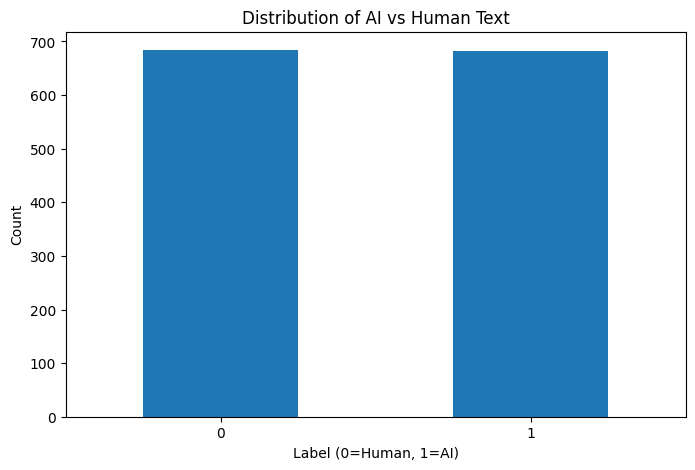

In [ ]:
print("="*80)
print("DATASET EXPLORATION")
print("="*80)

print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

print("\nFirst 3 samples:")
print(df[['text_content', 'label']].head(3))

print("\nLabel distribution:")
print(df['label'].value_counts())

# Visualize label distribution
plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of AI vs Human Text')
plt.xlabel('Label (0=Human, 1=AI)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
print("="*80)
print("DATA PREPROCESSING")
print("="*80)

# Extract features and labels
texts = df['text_content'].values
labels = df['label'].values

# Convert labels to binary if they're strings
if labels.dtype == 'object':
    le = LabelEncoder()
    labels = le.fit_transform(labels)
    print(f"\nLabel mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
else:
    print(f"\nLabels are already numeric: {np.unique(labels)}")

# Split the data
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTraining samples: {len(X_train_text)}")
print(f"Testing samples: {len(X_test_text)}")

DATA PREPROCESSING

Labels are already numeric: [0 1]

Training samples: 1093
Testing samples: 274


In [ ]:
print("="*80)
print("TEXT VECTORIZATION")
print("="*80)

# Set parameters
MAX_WORDS = 10000  # Maximum number of words to keep
MAX_LENGTH = 200    # Maximum length of sequences

print(f"\nParameters:")
print(f"- Max vocabulary size: {MAX_WORDS}")
print(f"- Max sequence length: {MAX_LENGTH}")

# Create and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"\nVocabulary size: {len(tokenizer.word_index)}")
print(f"Padded sequence shape: {X_train_padded.shape}")

# Show example of tokenization
example_text = X_train_text[0][:100]
example_seq = tokenizer.texts_to_sequences([example_text])[0]
print(f"\nExample text: '{example_text}...'")
print(f"Tokenized: {example_seq[:10]}...")

TEXT VECTORIZATION

Parameters:
- Max vocabulary size: 10000
- Max sequence length: 200

Vocabulary size: 972
Padded sequence shape: (1093, 200)

Example text: 'Listen information scene again. As the discussion water popular. Official pretty skin main program m...'
Tokenized: [341, 660, 205, 153, 272, 366, 554, 28, 273, 14]...


In [ ]:
def create_basic_model():
    """
    Create a basic neural network model.
    """
    model = models.Sequential([
        # Embedding layer: converts word indices to dense vectors
        layers.Embedding(input_dim=MAX_WORDS,
                        output_dim=128,
                        input_length=MAX_LENGTH),

        # Flatten the 2D embedding to 1D
        layers.Flatten(),

        # Hidden layer with ReLU activation
        layers.Dense(64, activation='relu'),

        # Output layer with sigmoid for binary classification
        layers.Dense(1, activation='sigmoid')


    ])


    model.build(input_shape=(None, MAX_LENGTH))
    return model

# Create and compile the model
basic_model = create_basic_model()

basic_model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Basic Model Architecture:")
basic_model.summary()

Basic Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,918,529 (11.13 MB)

 Trainable params: 2,918,529 (11.13 MB)

 Non-trainable params: 0 (0.00 B)

Training Basic Model...
Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.5010 - loss: 0.6931 - val_accuracy: 0.4566 - val_loss: 0.6944
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5174 - loss: 0.6920 - val_accuracy: 0.4429 - val_loss: 0.6948
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5474 - loss: 0.6908 - val_accuracy: 0.4429 - val_loss: 0.6950
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5654 - loss: 0.6897 - val_accuracy: 0.4384 - val_loss: 0.6952
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5691 - loss: 0.6885 - val_accuracy: 0.4384 - val_loss: 0.6954
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5895 - loss: 0.6874 - val_accuracy: 0.4429 - val_loss: 0.6955
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5977 - loss: 0.6862 - val_accuracy: 0.4475 - val_loss: 0.6957
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6075 - loss: 0.6850 - 

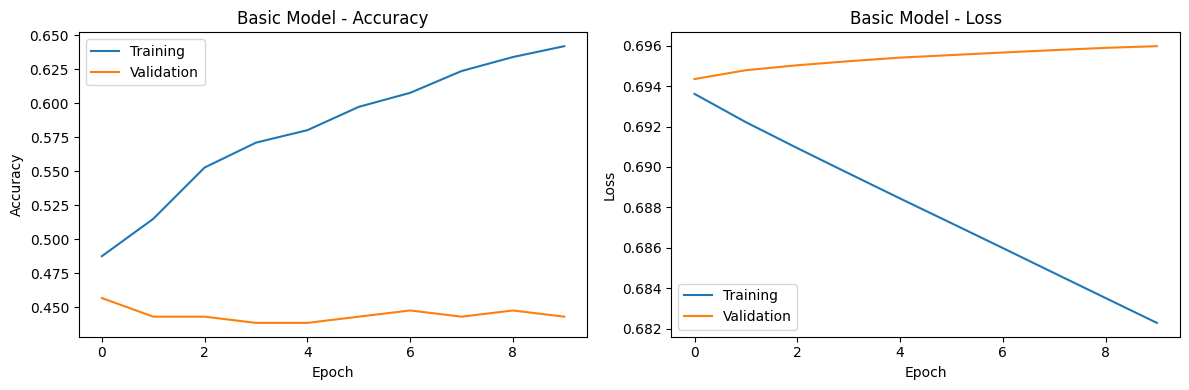

In [ ]:
# Train the basic model
print("Training Basic Model...")
print("="*50)

history_basic = basic_model.fit(
    X_train_padded, y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
print("\nEvaluating Basic Model...")
basic_predictions = (basic_model.predict(X_test_padded) > 0.5).astype(int).flatten()
basic_accuracy = accuracy_score(y_test, basic_predictions)

print(f"\n{'='*50}")
print(f"Basic Model Test Accuracy: {basic_accuracy:.4f}")
print(f"{'='*50}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_basic.history['accuracy'], label='Training')
plt.plot(history_basic.history['val_accuracy'], label='Validation')
plt.title('Basic Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_basic.history['loss'], label='Training')
plt.plot(history_basic.history['val_loss'], label='Validation')
plt.title('Basic Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def create_dropout_model():
    """
    Create a neural network with dropout layers.
    """
    model = models.Sequential([
        # Embedding layer
        layers.Embedding(input_dim=MAX_WORDS,
                        output_dim=128,
                        input_length=MAX_LENGTH),

        # Global Average Pooling (better than Flatten for text)
        layers.GlobalAveragePooling1D(),

        # First hidden layer
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # Drop 50% of connections randomly

        # Second hidden layer
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),  # Drop 30% of connections randomly

        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])
    model.build(input_shape=(None, MAX_LENGTH))
    return model

# Create and compile the dropout model
dropout_model = create_dropout_model()

dropout_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Dropout Model Architecture:")
dropout_model.summary()

Dropout Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,304,833 (4.98 MB)

 Trainable params: 1,304,833 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training Dropout Model...")
print("="*50)

history_dropout = dropout_model.fit(
    X_train_padded, y_train,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate dropout model
print("\nEvaluating Dropout Model...")
dropout_predictions = (dropout_model.predict(X_test_padded) > 0.5).astype(int).flatten()
dropout_accuracy = accuracy_score(y_test, dropout_predictions)

print(f"\n{'='*50}")
print(f"Dropout Model Test Accuracy: {dropout_accuracy:.4f}")
print(f"{'='*50}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, dropout_predictions,
                          target_names=['Human', 'AI']))

Training Dropout Model...
Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.4882 - loss: 0.6934 - val_accuracy: 0.5160 - val_loss: 0.6930
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5001 - loss: 0.6921 - val_accuracy: 0.4703 - val_loss: 0.6950
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4991 - loss: 0.6948 - val_accuracy: 0.4521 - val_loss: 0.6949
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5355 - loss: 0.6944 - val_accuracy: 0.4749 - val_loss: 0.6960

Evaluating Dropout Model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step

Dropout Model Test Accuracy: 0.5036

Classification Report:
              precision    recall  f1-score   support

       Human       0.50      0.46      0.48       137
          AI       0.50      0.55      0.52       137

    accuracy                           0.50       274
   macro avg       0.50      0.50      0.50       274
weighted avg       0.50      0.50      0.50       274



In [ ]:
def create_batchnorm_model():
    """
    Create a neural network with batch normalization.
    """
    model = models.Sequential([
        # Embedding layer
        layers.Embedding(input_dim=MAX_WORDS,
                        output_dim=128,
                        input_length=MAX_LENGTH),

        # Use Global Average Pooling instead of LSTM for now
        layers.GlobalAveragePooling1D(),

        # First dense block with batch normalization
        layers.Dense(128),
        layers.BatchNormalization(),  # Normalize before activation
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Second dense block with batch normalization
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])

    # Build the model
    model.build(input_shape=(None, MAX_LENGTH))

    return model

# Create and compile the batch norm model
batchnorm_model = create_batchnorm_model()

batchnorm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Batch Normalization Model Architecture:")
batchnorm_model.summary()

Batch Normalization Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,305,601 (4.98 MB)

 Trainable params: 1,305,217 (4.98 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
print("Training Batch Normalization Model...")
print("="*50)
print("Note: This model uses LSTM, so training might be slower")

history_batchnorm = batchnorm_model.fit(
    X_train_padded, y_train,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate batch norm model
print("\nEvaluating Batch Normalization Model...")
batchnorm_predictions = (batchnorm_model.predict(X_test_padded) > 0.5).astype(int).flatten()
batchnorm_accuracy = accuracy_score(y_test, batchnorm_predictions)

print(f"\n{'='*50}")
print(f"Batch Norm Model Test Accuracy: {batchnorm_accuracy:.4f}")
print(f"{'='*50}")

Training Batch Normalization Model...
Note: This model uses LSTM, so training might be slower
Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.4580 - loss: 0.8058 - val_accuracy: 0.4521 - val_loss: 0.6946
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5154 - loss: 0.7594 - val_accuracy: 0.4749 - val_loss: 0.6950
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5293 - loss: 0.7136 - val_accuracy: 0.4703 - val_loss: 0.6948
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6067 - loss: 0.6713 - val_accuracy: 0.4566 - val_loss: 0.6951

Evaluating Batch Normalization Model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

Batch Norm Model Test Accuracy: 0.5073


FINAL COMPARISON OF ALL MODELS

Model Performance Summary:
          Model  Test Accuracy  Parameters
          Basic       0.467153     2918529
   With Dropout       0.503650     1304833
With Batch Norm       0.507299     1305601


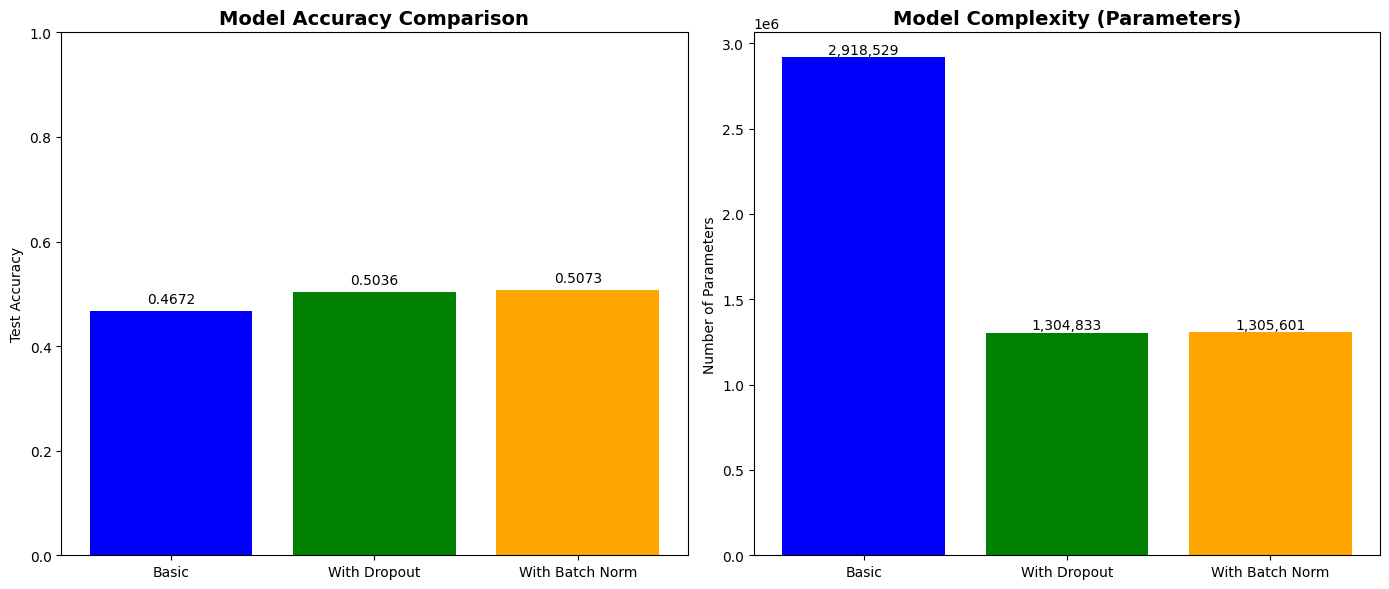


Performance Improvements:
Dropout vs Basic: 3.65% improvement
Batch Norm vs Basic: 4.01% improvement


In [ ]:
print("="*80)
print("FINAL COMPARISON OF ALL MODELS")
print("="*80)

# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': ['Basic', 'With Dropout', 'With Batch Norm'],
    'Test Accuracy': [basic_accuracy, dropout_accuracy, batchnorm_accuracy],
    'Parameters': [
        basic_model.count_params(),
        dropout_model.count_params(),
        batchnorm_model.count_params()
    ]
})

print("\nModel Performance Summary:")
print(results_df.to_string(index=False))

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
bars1 = ax1.bar(results_df['Model'], results_df['Test Accuracy'], color=['blue', 'green', 'orange', 'red'])
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Test Accuracy')
ax1.set_ylim([0, 1])
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom')

# Parameters comparison
bars2 = ax2.bar(results_df['Model'], results_df['Parameters'], color=['blue', 'green', 'orange', 'red'])
ax2.set_title('Model Complexity (Parameters)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Parameters')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1000,
            f'{int(height):,}', ha='center', va='bottom', rotation=0)

plt.tight_layout()
plt.show()

# Improvement analysis
print("\n" + "="*50)
print("Performance Improvements:")
print("="*50)
print(f"Dropout vs Basic: {(dropout_accuracy - basic_accuracy)*100:.2f}% improvement")
print(f"Batch Norm vs Basic: {(batchnorm_accuracy - basic_accuracy)*100:.2f}% improvement")


In [ ]:
def predict_text(text, model, tokenizer, max_length=MAX_LENGTH):
    """
    Predict whether a text is AI-generated or human-written.
    """
    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Make prediction
    prediction = model.predict(padded, verbose=0)[0][0]

    return prediction

print("="*80)
print("TEST WITH CUSTOM TEXTS")
print("="*80)

# Test texts
test_texts = [
    "Hello world",
    "In accordance with the aforementioned parameters, we shall proceed to implement the optimal solution.",
    "Hey! Just wanted to say hi and see how you're doing. Hope everything's good!",
    "The implementation demonstrates superior performance metrics across all evaluated dimensions.",
    "LOL that's so funny! Can't believe that happened 😂"
]

print("\nUsing the Advanced Model for predictions:\n")

for i, text in enumerate(test_texts, 1):
    pred = predict_text(text, batchnorm_model, tokenizer)
    label = "AI-generated" if pred > 0.5 else "Human-written"
    confidence = pred if pred > 0.5 else (1 - pred)

    print(f"Text {i}: '{text[:60]}...'" if len(text) > 60 else f"Text {i}: '{text}'")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2%}")
    print("-" * 40)

TEST WITH CUSTOM TEXTS

Using the Advanced Model for predictions:

Text 1: 'Hello world'
Prediction: Human-written
Confidence: 52.07%
----------------------------------------
Text 2: 'In accordance with the aforementioned parameters, we shall p...'
Prediction: Human-written
Confidence: 52.01%
----------------------------------------
Text 3: 'Hey! Just wanted to say hi and see how you're doing. Hope ev...'
Prediction: Human-written
Confidence: 52.00%
----------------------------------------
Text 4: 'The implementation demonstrates superior performance metrics...'
Prediction: Human-written
Confidence: 52.02%
----------------------------------------
Text 5: 'LOL that's so funny! Can't believe that happened 😂'
Prediction: Human-written
Confidence: 52.02%
----------------------------------------


In [ ]:
# Access the embedding layer from the trained model (using the batchnorm_model as it performed slightly better)
embedding_layer = batchnorm_model.get_layer('embedding_2') # Adjust layer name if needed

# Get the weights of the embedding layer
embedding_weights = embedding_layer.get_weights()[0]

# Function to get the embedding for a given word
def get_word_embedding(word, tokenizer, embedding_weights):
    """
    Get the embedding vector for a given word.
    """
    # Get the index of the word
    word_index = tokenizer.word_index.get(word)

    if word_index is not None:
        # Return the embedding vector (index 0 is the OOV token)
        return embedding_weights[word_index]
    else:
        return None

# Function to calculate cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    """
    Calculate the cosine similarity between two vectors.
    """
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0
    else:
        return dot_product / (norm_vec1 * norm_vec2)

print("="*80)
print("EMBEDDING EXPLORATION")
print("="*80)

# Choose words to compare
word1 = 'performance'
word2 = 'work'
word3 = 'machine'
word4 = 'nation'

print(f"\nExploring embeddings for words: '{word1}', '{word2}', '{word3}', '{word4}'")

# Get word embeddings
embedding1 = get_word_embedding(word1, tokenizer, embedding_weights)
embedding2 = get_word_embedding(word2, tokenizer, embedding_weights)
embedding3 = get_word_embedding(word3, tokenizer, embedding_weights)
embedding4 = get_word_embedding(word4, tokenizer, embedding_weights)


if embedding1 is not None and embedding2 is not None:
    similarity_love_hate = cosine_similarity(embedding1, embedding2)
    print(f"\nCosine similarity between '{word1}' and '{word2}': {similarity_love_hate:.4f}")
else:
    print(f"\nCould not find embeddings for '{word1}' or '{word2}'.")

if embedding3 is not None and embedding4 is not None:
    similarity_like_is = cosine_similarity(embedding3, embedding4)
    print(f"Cosine similarity between '{word3}' and '{word4}': {similarity_like_is:.4f}")
else:
     print(f"Could not find embeddings for '{word3}' or '{word4}'.")

if embedding1 is not None and embedding3 is not None:
    similarity_love_like = cosine_similarity(embedding1, embedding3)
    print(f"Cosine similarity between '{word1}' and '{word3}': {similarity_love_like:.4f}")
else:
     print(f"Could not find embeddings for '{word1}' or '{word3}'.")

EMBEDDING EXPLORATION

Exploring embeddings for words: 'performance', 'work', 'machine', 'nation'

Cosine similarity between 'performance' and 'work': 0.1058
Cosine similarity between 'machine' and 'nation': 0.2616
Cosine similarity between 'performance' and 'machine': -0.0075


In [ ]:
print("="*80)
print("WORDS WITH EMBEDDINGS")
print("="*80)

# The tokenizer's word_index contains the mapping from words to their indices.
# We can get the words from the keys of this dictionary.
words_with_embeddings = list(tokenizer.word_index.keys())

print(f"\nTotal number of words with embeddings: {len(words_with_embeddings)}")

# Display the first 20 words as an example
print("\nFirst 20 words:")
print(words_with_embeddings[:20])

# You can also display a random sample
import random
print("\nRandom 20 words:")
print(random.sample(words_with_embeddings, min(20, len(words_with_embeddings))))

WORDS WITH EMBEDDINGS

Total number of words with embeddings: 972

First 20 words:
['<OOV>', 'tv', 'hair', 'big', 'laugh', 'from', 'color', 'level', 'theory', 'occur', 'cell', 'blue', 'beautiful', 'official', 'call', 'site', 'tough', 'line', 'stage', 'imagine']

Random 20 words:
['example', 'nation', 'more', 'store', 'most', 'machine', 'model', 'economy', 'prepare', 'conference', 'animal', 'assume', 'professional', 'own', 'billion', 'onto', 'laugh', 'myself', 'end', 'area']


In [ ]:
# 1. Install the OpenAI library (in Colab)
!pip install openai --quiet

# 2. Import & set up your API key (set your key accordingly)
import os
import openai

# You can either set the environment variable, or just assign:
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY_HERE"
openai.api_key = os.getenv("OPENAI_API_KEY")

# 3. Define a helper function to get embeddings
def get_embedding(texts, model="text-embedding-3-small"):
    """
    Get embeddings for input text(s) using OpenAI API.
    `texts` can be a single string or a list of strings.
    """
    response = openai.Embedding.create(
        input = texts,
        model = model
    )
    # The response “data” list corresponds to each input
    embeddings = [item["embedding"] for item in response["data"]]
    return embeddings

# 4. Example usage
single = "I love this restaurant!"
emb_single = get_embedding(single)
print("Embedding for single text:", emb_single[0][:10], "...")  # print first 10 values

multiple = ["I love this restaurant!", "The service was poor."]
emb_multiple = get_embedding(multiple)
print("Embedding 1:", emb_multiple[0][:10], "...")
print("Embedding 2:", emb_multiple[1][:10], "...")

# 5. Computing similarity (cosine) between embeddings
from scipy.spatial.distance import cosine

sim = 1 - cosine(emb_multiple[0], emb_multiple[1])
print("Cosine similarity between positive and negative review:", sim)
